# Ion Identification Training Data Analysis

Explore the distributions in the `training_data/` datasets used by the Ionclassifier / RF / KDE models: element & molecule coverage, charge states, mass-to-charge (`mc`) values, and peak counts.

In [1]:
import random
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import re

%matplotlib inline
pd.set_option("display.max_columns", None)

In [2]:
# Pick which generated dataset to analyze
TRAINING_DATA_ROOT = Path("../training_data")
DATASET_NAME = "NewData_truthcoverage_lightmol1p_C3_BO_C2O_2p_2026-06-10"
DATASET_DIR = TRAINING_DATA_ROOT / DATASET_NAME

# Per-spectrum CSVs can number in the thousands; sample a subset for speed (None = load all)
N_FILES_TO_SAMPLE = 300
RANDOM_SEED = 0

print(sorted(p.name for p in TRAINING_DATA_ROOT.iterdir() if p.is_dir()))

['NewData', 'NewData_peakshift0_noise0', 'NewData_peakshift0_noise0_newchg', 'NewData_peakshift2_noise5', 'NewData_truthcoverage_lightmol1p_C3_BO_C2O_2p_2026-06-10']


## Element & molecule coverage summaries

These summary CSVs (generated alongside the dataset) already aggregate sample/file counts per truth element and molecule.

In [3]:
element_summary_path = DATASET_DIR / "truth_element_coverage_summary.csv"
molecule_summary_path = DATASET_DIR / "truth_molecule_coverage_summary.csv"
charge_state_path = next(DATASET_DIR.glob("MostCommonChargeState*.csv"), None)

element_df = pd.read_csv(element_summary_path) if element_summary_path.exists() else None
molecule_df = pd.read_csv(molecule_summary_path) if molecule_summary_path.exists() else None
charge_state_df = pd.read_csv(charge_state_path) if charge_state_path else None

element_df.head() if element_df is not None else "no element summary found"

,element,sample_count,file_count,charges
0,Ag,960,480,1
1,Al,1887,629,1;2;3
2,Ar,6,2,1
3,As,660,330,1;2
4,Au,654,327,1;2


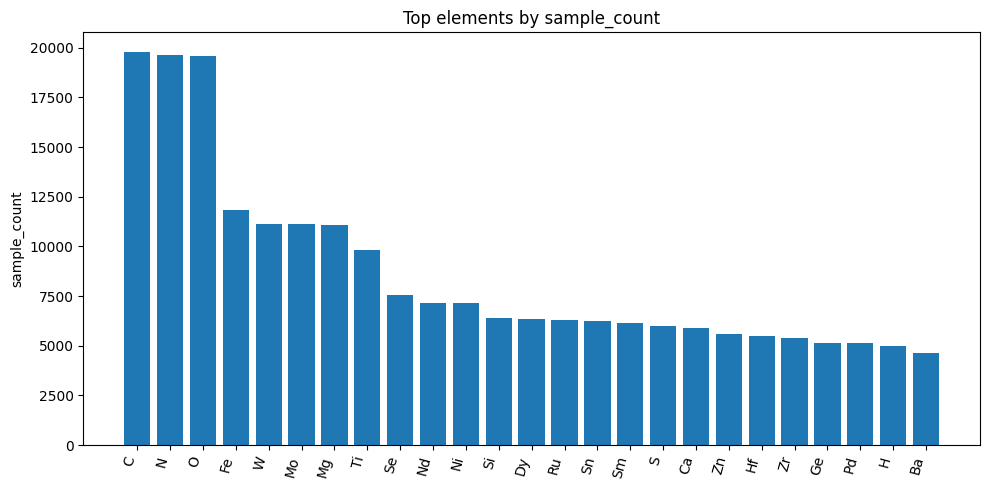

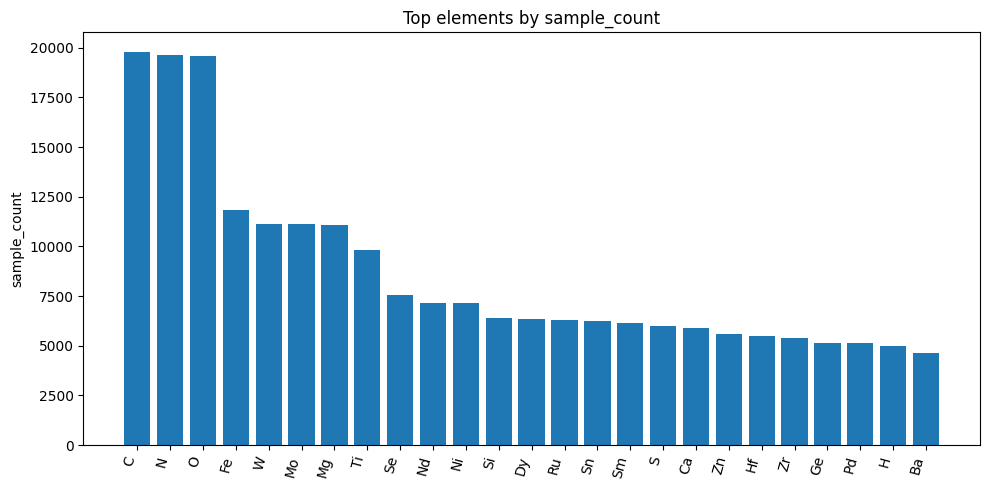

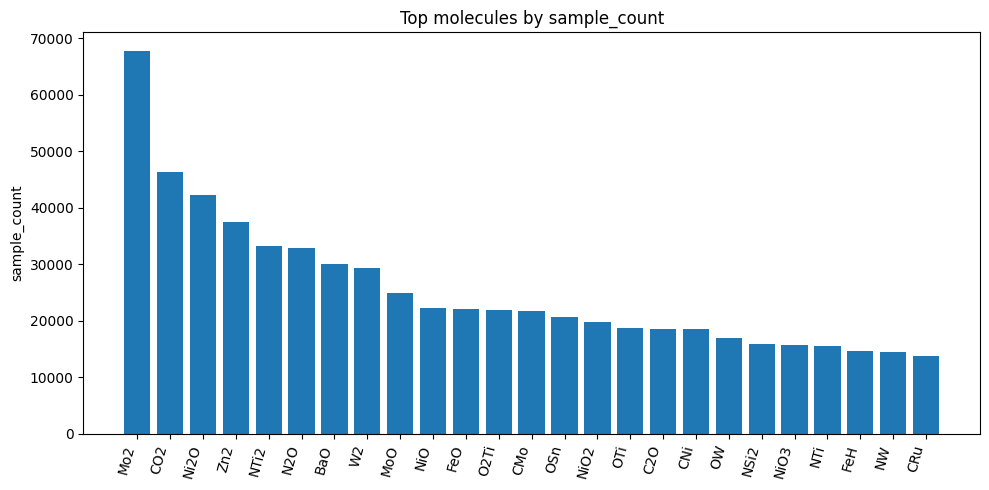

In [4]:
def plot_top_n(df, label_col, value_col, title, n=25):
    top = df.sort_values(value_col, ascending=False).head(n)
    plt.figure(figsize=(10, 5))
    plt.bar(top[label_col], top[value_col])
    plt.xticks(rotation=75, ha="right")
    plt.ylabel(value_col)
    plt.title(title)
    plt.tight_layout()
    plt.show()


if element_df is not None:
    plot_top_n(element_df, "element", "sample_count", "Top elements by sample_count")

if molecule_df is not None:
    plot_top_n(molecule_df, "canonical_formula", "sample_count", "Top molecules by sample_count")

### Validate `truth_element_coverage_summary.csv` and `truth_molecule_coverage_summary.csv`

`sample_count` = total peak rows across the dataset labeled as that bare element (e.g. `"C"`, not `"CO2"` or `"H2"`).
`file_count` = number of distinct spectrum files containing that element at least once.

Recompute both directly from the raw per-spectrum CSVs (full dataset, not the sampled `spectra_df`) and diff against the summary CSV.

In [14]:
ELEMENT_RE = re.compile(r"^[A-Z][a-z]?$")  # bare single-atom label, e.g. "H", "Cl" (not "H2", "CO2", "OOO")

def load_spectra(dataset_dir, n_files=None, seed=0):
    csv_paths = sorted(dataset_dir.glob("Data*/*.csv"))
    if n_files is not None and n_files < len(csv_paths):
        csv_paths = random.Random(seed).sample(csv_paths, n_files)

    frames = []
    for p in csv_paths:
        df = pd.read_csv(p)
        df["source_file"] = f"{p.parent.name}/{p.name}"
        frames.append(df)
    return pd.concat(frames, ignore_index=True)


def chemical_species_hits(df, re_match):
    cols = [("ion", "charge"), ("ion2", "charge2")]
    hits = pd.concat(
        [df[[ion_col, charge_col, "source_file"]].rename(columns={ion_col: "element", charge_col: "charge"})
         for ion_col, charge_col in cols],
        ignore_index=True,
    ).dropna(subset=["element"])
    return hits[hits["element"].str.match(re_match)]


# Load every spectrum in the dataset -- the summary CSV was computed over the full dataset, not a sample
full_spectra_df = load_spectra(DATASET_DIR, n_files=None)
element_hits = chemical_species_hits(full_spectra_df, ELEMENT_RE)

element_recomputed = element_hits.groupby("element").agg(
    sample_count=("element", "size"),
    file_count=("source_file", "nunique"),
    charges=("charge", lambda s: ";".join(str(int(c)) for c in sorted(s.unique()))),
).reset_index()

element_comparison = element_df.merge(element_recomputed, on="element", suffixes=("_csv", "_recomputed"), how="outer", indicator=True)
element_comparison["sample_count_match"] = element_comparison["sample_count_csv"] == element_comparison["sample_count_recomputed"]
element_comparison["file_count_match"] = element_comparison["file_count_csv"] == element_comparison["file_count_recomputed"]

mismatches = element_comparison[~(element_comparison["sample_count_match"] & element_comparison["file_count_match"])]
print(f"{len(element_comparison)} elements compared, {len(mismatches)} mismatch(es)")
mismatches

86 elements compared, 10 mismatch(es)


,element,sample_count_csv,file_count_csv,charges_csv,sample_count_recomputed,file_count_recomputed,charges_recomputed,_merge,sample_count_match,file_count_match
12,Cd,NaN,NaN,NaN,2379,340,1,right_only,False,False
21,Eu,NaN,NaN,NaN,1985,331,1;2;3,right_only,False,False
31,Ho,NaN,NaN,NaN,777,259,1;2;3,right_only,False,False
36,Kr,NaN,NaN,NaN,12,2,1,right_only,False,False
39,Lu,NaN,NaN,NaN,1452,242,1;2;3,right_only,False,False
69,Sr,NaN,NaN,NaN,2623,656,1,right_only,False,False
73,Te,NaN,NaN,NaN,3583,512,1,right_only,False,False
74,Th,NaN,NaN,NaN,168,168,1,right_only,False,False
77,Tm,NaN,NaN,NaN,726,242,1;2;3,right_only,False,False
83,Yb,NaN,NaN,NaN,314,15,1;2;3,right_only,False,False


In [24]:
MOLECULE_RE = re.compile(r"^(?:[A-Z][a-z]?\d*){2,}$|^[A-Z][a-z]?\d+$")  # 2+ element groups, or a single element with a count

molecule_hits = chemical_species_hits(full_spectra_df, MOLECULE_RE).rename(columns={"element": "canonical_formula"})

molecule_recomputed = molecule_hits.groupby("canonical_formula").agg(
    sample_count=("canonical_formula", "size"),
    file_count=("source_file", "nunique"),
    charges=("charge", lambda s: ";".join(str(int(c)) for c in sorted(s.unique()))),
).reset_index()

molecule_comparison = molecule_df.merge(molecule_recomputed, on="canonical_formula", suffixes=("_csv", "_recomputed"), how="outer", indicator=True)
molecule_comparison["sample_count_match"] = molecule_comparison["sample_count_csv"] == molecule_comparison["sample_count_recomputed"]
molecule_comparison["file_count_match"] = molecule_comparison["file_count_csv"] == molecule_comparison["file_count_recomputed"]

mismatches = molecule_comparison[~(molecule_comparison["sample_count_match"] & molecule_comparison["file_count_match"])]
print(f"{len(molecule_comparison)} elements compared, {len(mismatches)} mismatch(es)")
mismatches

135 elements compared, 5 mismatch(es)


,canonical_formula,sample_count_csv,file_count_csv,charges_csv,sample_count_recomputed,file_count_recomputed,charges_recomputed,_merge,sample_count_match,file_count_match
22,BNaSi,NaN,NaN,NaN,176,15,1;2;3;4,right_only,False,False
69,HHOO,NaN,NaN,NaN,3167,2467,1,right_only,False,False
117,OOO,NaN,NaN,NaN,50549,4967,1;2;3;4,right_only,False,False
133,ZrS,NaN,NaN,NaN,3877,84,1;2;3;4,right_only,False,False
134,ZrZrOOOO,NaN,NaN,NaN,8874,220,1;2;3;4,right_only,False,False


## Per-spectrum peak data

Each `Data000X/NNNNNN.csv` file is one synthetic spectrum with columns `mc, counts, ion, charge, ion2, charge2` (`ion2`/`charge2` present when two ions overlap at the same `mc`).

In [25]:
spectra_df = load_spectra(DATASET_DIR, n_files=None, seed=RANDOM_SEED)
print(f"Loaded {spectra_df['source_file'].nunique()} spectra, {len(spectra_df)} peak rows")
spectra_df.head()

Loaded 5000 spectra, 1184325 peak rows


,mc,counts,ion,charge,ion2,charge2,source_file
0,1.02,13464672,H,1.0,NaN,NaN,Data0001/000000.csv
1,1.98,88126,H2,1.0,NaN,NaN,Data0001/000000.csv
2,2.97,1595,H3,1.0,NaN,NaN,Data0001/000000.csv
3,5.98,4432207,C,2.0,NaN,NaN,Data0001/000000.csv
4,6.49,49307,C,2.0,NaN,NaN,Data0001/000000.csv


In [29]:
spectra_df[spectra_df["ion"] == "OOO"]

,mc,counts,ion,charge,ion2,charge2,source_file
47,47.970000,2504,OOO,1.0,NaN,NaN,Data0001/000000.csv
75,11.990000,3649499,OOO,4.0,C,1.0,Data0001/000001.csv
76,12.480000,18721,OOO,4.0,OOO,4.0,Data0001/000001.csv
88,16.616667,4496,OOO,3.0,NaN,NaN,Data0001/000001.csv
89,16.666667,6495,OOO,3.0,NaN,NaN,Data0001/000001.csv
...,...,...,...,...,...,...,...
1184203,25.050000,16698,OOO,2.0,OOO,2.0,Data0001/004999.csv
1184261,47.970000,6119735,OOO,1.0,NaN,NaN,Data0001/004999.csv
1184262,50.010000,24538,OOO,1.0,OOO,1.0,Data0001/004999.csv
1184263,50.050000,12265,OOO,1.0,NaN,NaN,Data0001/004999.csv


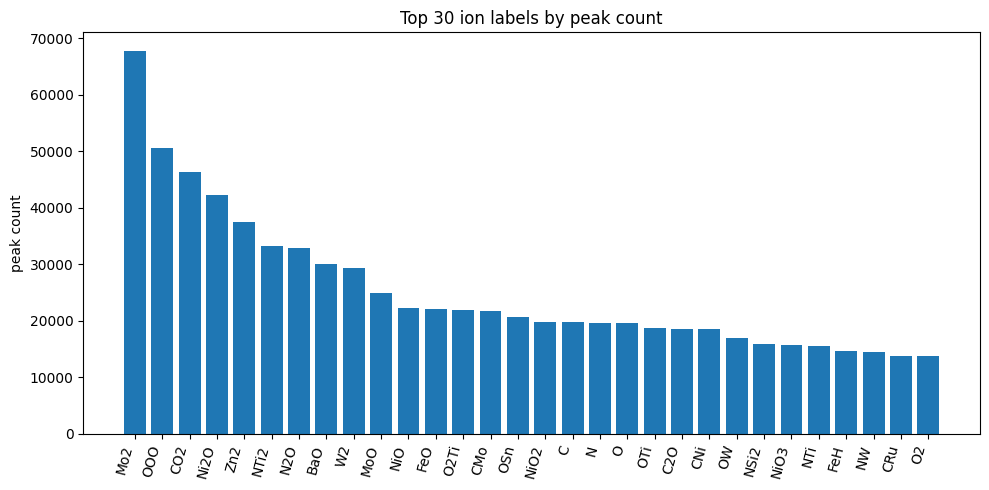

In [26]:
# Ion label distribution (combine primary + overlapping second ion)
ion_labels = pd.concat([spectra_df["ion"], spectra_df["ion2"]]).dropna()
ion_counts = ion_labels.value_counts().head(30)

plt.figure(figsize=(10, 5))
plt.bar(ion_counts.index, ion_counts.values)
plt.xticks(rotation=75, ha="right")
plt.ylabel("peak count")
plt.title("Top 30 ion labels by peak count")
plt.tight_layout()
plt.show()

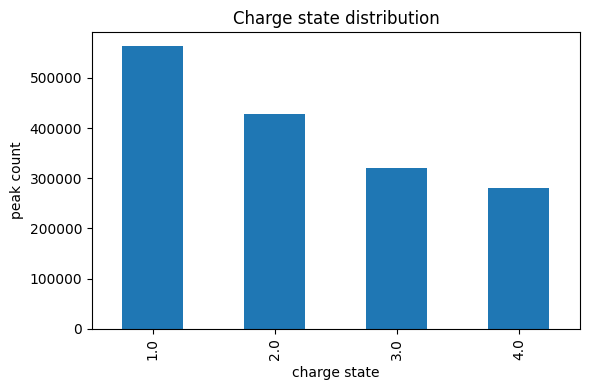

In [27]:
# Charge state distribution (combine primary + second charge)
charges = pd.concat([spectra_df["charge"], spectra_df["charge2"]]).dropna()

plt.figure(figsize=(6, 4))
charges.value_counts().sort_index().plot(kind="bar")
plt.xlabel("charge state")
plt.ylabel("peak count")
plt.title("Charge state distribution")
plt.tight_layout()
plt.show()

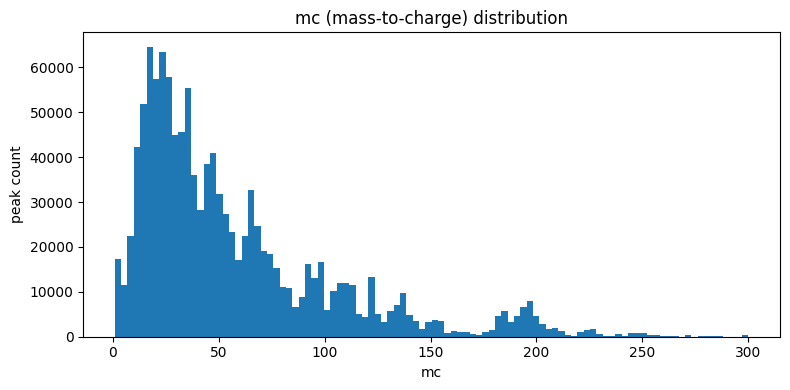

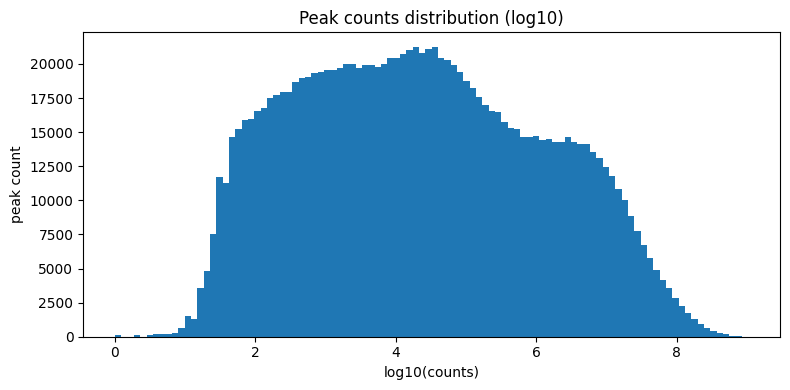

In [28]:
# mc (mass-to-charge) distribution
plt.figure(figsize=(8, 4))
plt.hist(spectra_df["mc"], bins=100)
plt.xlabel("mc")
plt.ylabel("peak count")
plt.title("mc (mass-to-charge) distribution")
plt.tight_layout()
plt.show()

# counts distribution (log-scale, spans several orders of magnitude)
plt.figure(figsize=(8, 4))
plt.hist(np.log10(spectra_df["counts"].clip(lower=1)), bins=100)
plt.xlabel("log10(counts)")
plt.ylabel("peak count")
plt.title("Peak counts distribution (log10)")
plt.tight_layout()
plt.show()

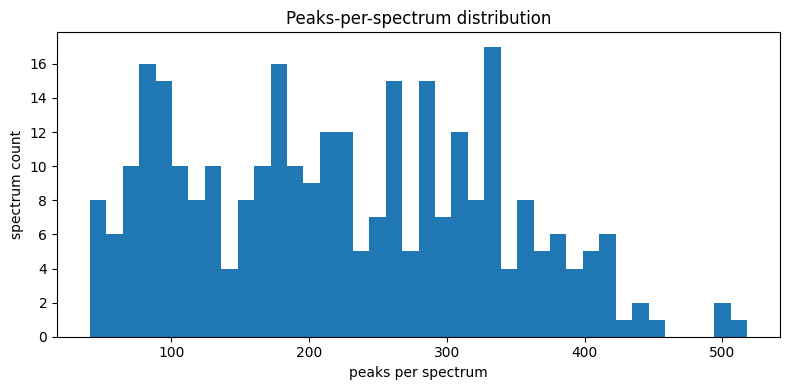

count    300.00000
mean     223.55000
std      109.19153
min       41.00000
25%      128.25000
50%      218.00000
75%      310.50000
max      518.00000
dtype: float64

In [11]:
# Peaks per spectrum
peaks_per_spectrum = spectra_df.groupby("source_file").size()

plt.figure(figsize=(8, 4))
plt.hist(peaks_per_spectrum, bins=40)
plt.xlabel("peaks per spectrum")
plt.ylabel("spectrum count")
plt.title("Peaks-per-spectrum distribution")
plt.tight_layout()
plt.show()

peaks_per_spectrum.describe()